# VERITAS 03 — Pretraining

**Phase 3 of 16.** Data pipeline → training loop → perplexity.

## The data pipeline, and why each stage exists

```
raw text → clean → quality filter → dedup → tokenize → uint16 memmap → batches
```

* **clean** — NFKC normalise. The same visible string has several byte
  encodings (full-width digits, ligatures, NBSP). Without normalisation the
  tokenizer learns separate merges per variant *and* entity matching in the
  evidence layer silently fails.
* **quality filter** — C4/Gopher heuristics. Each rejects a known failure:
  too short (no structure), symbol-heavy (nav bars, base64), degenerate words
  (OCR noise), repetitive (spam).
* **dedup (MinHash + LSH)** — web corpora are 20–50 % duplicated. Duplicates
  waste compute and cause memorisation. MinHash estimates Jaccard in `O(k)`
  per doc; LSH banding turns `O(N²)` all-pairs into `O(N)` bucket lookups.
* **uint16 memmap** — vocab ≤ 65535 ⇒ 2 bytes/token. The OS pages it in on
  demand: RAM is `O(batch)`, start-up is instant, workers share it.
* **random-offset sampling** — `O(1)` per sample and unbiased. A shuffled list
  of every window is `O(N)` memory and destroys locality.

## The optimisation recipe

| component | why |
|---|---|
| **AdamW** | classic L2 gets divided by `√v`, so high-variance params end up barely regularised. AdamW applies `p −= lr·wd·p` separately. Decay **matrices only** — shrinking RMSNorm gains and biases just breaks the residual scale. |
| **warmup → cosine** | at step 0 Adam's `v ≈ 0`, so the effective step is enormous and one bad batch destroys the init. Cosine then anneals to `lr/10`; the late small steps do the fine fitting. |
| **grad accumulation** | gradient noise `∝ 1/√B`, but `B` is capped by VRAM. Accumulating `k` micro-batches gives the statistics of `k·B` at the memory of `B`. |
| **bf16 autocast** | fp32's exponent range with fewer mantissa bits: ~2× throughput/memory, and unlike fp16 it cannot overflow — no GradScaler needed. |
| **clip at norm 1.0** | language data is heavy-tailed; one odd batch can produce a 100× gradient and undo hours of training. |

In [1]:
import sys, os, time, math, json, random
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, torch
torch.manual_seed(1337); np.random.seed(1337); random.seed(1337)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch', torch.__version__)
if DEVICE == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0),
          f'| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

device: cuda | torch 2.11.0+cu128
gpu: NVIDIA GeForce RTX 5060 Laptop GPU | 8.5 GB


In [2]:
from veritas.tokenizer.bpe import BPETokenizer
from veritas.train.data import (clean_text, quality_filter, dedupe, build_shard,
                                split_shard, TokenDataset, MinHashDeduper)
from veritas.train.trainer import TrainConfig, train, cosine_lr, estimate_loss
from veritas.model.transformer import ModelConfig, VeritasLM

tok = BPETokenizer.load(ROOT/'checkpoints'/'tokenizer.json')
print('vocab:', tok.vocab_size)

vocab: 624


## Step 1 — build the document list

Point `docs` at your own corpus. One string per document. Legally usable
sources only: public-domain text, permissively-licensed datasets, your own
documents, open government data.

In [3]:
raw_dir = ROOT/'data'/'raw'
docs = []
for p in sorted(raw_dir.glob('*.txt')):
    docs.extend([d for d in p.read_text(encoding='utf-8').split('\n\n\n') if d.strip()])
if not docs:
    # Stand-in corpus: varied enough to survive dedup and to give the model
    # some real structure to learn. Every document is distinct.
    from veritas.eval.benchmark import build_seed_benchmark, expand_synthetic
    bench = expand_synthetic(build_seed_benchmark(), 60)
    base = [d.text for it in bench.items for d in it.docs]
    rng = random.Random(0)
    firms = ['Cobalt Works','Vireo Health','Northwind Rail','Stellar Foods','Kestrel Bank',
             'Orion Systems','Helios Energy','Meridian Port','Nova Logistics','Acme Industries']
    people = ['Alicia Moreau','Tomas Berg','Hana Suzuki','Emeka Obi','Lena Petrov','Raj Malhotra']
    attrs = ['revenue','headcount','valuation','operating margin','order backlog']
    docs = list(base)
    for i in range(3000):
        f, p_, a = rng.choice(firms), rng.choice(people), rng.choice(attrs)
        y = rng.randint(2019, 2027); v = rng.randint(100, 9999)
        docs.append(
            f'{f} annual report {y}. The chief executive is {p_}, appointed in {y-1}. '
            f'The company reported {a} of {v/10:.1f} million euros for the {y} fiscal year, '
            f'compared with {v/11:.1f} million in {y-1}. Operations expanded to {rng.randint(2,40)} '
            f'sites. The board confirmed the figures at its meeting in {rng.choice(["March","June","September"])} {y}.')
    print(f'no data/raw/*.txt — generated {len(docs):,} distinct stand-in documents.')
    print('REPLACE THIS with a real corpus before reporting any perplexity number.')
print(f'{len(docs):,} documents | {sum(len(d) for d in docs):,} chars')

no data/raw/*.txt — generated 3,263 distinct stand-in documents.
REPLACE THIS with a real corpus before reporting any perplexity number.
3,263 documents | 928,202 chars


## Step 2 — clean, filter, dedup

Watch the survival rate at each stage. On real web data expect roughly
60–80 % surviving the quality filter and 50–80 % surviving dedup. If dedup
removes almost nothing, your corpus is probably already curated; if it removes
almost everything, check that you are not feeding the same document repeatedly.

In [4]:
t0 = time.time()
cleaned = [clean_text(d) for d in docs]
filtered = [d for d in cleaned if quality_filter(d, min_chars=80)]
deduped = list(dedupe(filtered))
print(f'raw       {len(docs):>7,}')
print(f'cleaned   {len(cleaned):>7,}')
print(f'filtered  {len(filtered):>7,}  ({100*len(filtered)/max(1,len(cleaned)):.0f}% survive)')
print(f'deduped   {len(deduped):>7,}  ({100*len(deduped)/max(1,len(filtered)):.0f}% survive)')
print(f'{time.time()-t0:.1f}s')

raw         3,263
cleaned     3,263
filtered    3,136  (96% survive)
deduped     2,474  (79% survive)
1.1s


In [5]:
# How MinHash+LSH decides: near-duplicates collide in at least one band.
d = MinHashDeduper(num_perm=128, bands=16)
a = 'Acme Industries reported revenue of 1.2 billion euros for the 2025 fiscal year.'
print('original      ->', d.add(0, a))
print('exact copy    ->', d.add(1, a))
print('minor edit    ->', d.add(2, a.replace('1.2', '1.2 ')))
print('genuinely new ->', d.add(3, 'Nova Logistics opened twelve offices across India in 2026.'))
print('\nP(collide) = 1-(1-J^r)^b  with b=16,r=8 -> threshold ≈ (1/16)^(1/8) ≈ 0.71 Jaccard')

original      -> True
exact copy    -> False
minor edit    -> False
genuinely new -> True

P(collide) = 1-(1-J^r)^b  with b=16,r=8 -> threshold ≈ (1/16)^(1/8) ≈ 0.71 Jaccard


## Step 3 — tokenize into a memmapped shard

Documents are concatenated EOS-separated into one flat `uint16` stream rather
than padded to a fixed length: padding a 512-token window to fit a 40-token
document wastes >90 % of the FLOPs.

In [6]:
shard = ROOT/'data'/'processed'/'train_full.bin'
t0 = time.time()
n_tokens = build_shard(deduped, tok, shard)
print(f'{n_tokens:,} tokens in {time.time()-t0:.1f}s -> {shard} ({shard.stat().st_size/1e6:.1f} MB)')
n_train, n_val = split_shard(shard, shard.with_name('train.bin'), shard.with_name('val.bin'), val_frac=0.02)
print(f'train {n_train:,} | val {n_val:,}  (contiguous tail split — a random split leaks)')

359,747 tokens in 0.4s -> C:\VERITAS\data\processed\train_full.bin (0.7 MB)
train 352,553 | val 7,194  (contiguous tail split — a random split leaks)


### Sizing the run (Chinchilla)

Compute-optimal is roughly **20 tokens per parameter**. Below that the model is
data-starved and will overfit; far above it you are spending compute that a
bigger model would use better. Use this to pick `max_steps`.

In [7]:
SEQ_LEN, BATCH, ACCUM = 256, 16, 4
cfg = ModelConfig(vocab_size=tok.vocab_size, d_model=384, n_layers=8, n_heads=8,
                  n_kv_heads=2, max_seq_len=SEQ_LEN, dropout=0.0)
model = VeritasLM(cfg)
P = model.num_params()
tokens_per_step = BATCH*ACCUM*SEQ_LEN
print(f'params {P:,} | Chinchilla-optimal ≈ {20*P:,} training tokens')
print(f'available: {n_train:,} tokens ({n_train/P:.1f} tokens/param)')
print(f'tokens/step {tokens_per_step:,} | one epoch = {n_train//tokens_per_step:,} steps')
if n_train < 20*P:
    print('\nData-limited: use dropout > 0, fewer steps, or a smaller d_model/n_layers.')

params 12,632,448 | Chinchilla-optimal ≈ 252,648,960 training tokens
available: 352,553 tokens (0.0 tokens/param)
tokens/step 16,384 | one epoch = 21 steps

Data-limited: use dropout > 0, fewer steps, or a smaller d_model/n_layers.


## Step 4 — train

Watch three things:
1. **loss** falls fast then slowly — a flat line means the LR is too low or the
   data is broken; a spike to NaN means it is too high.
2. **grad_norm** stabilises around 0.2–1.0. Persistently pinned at the clip
   value means the LR is too high.
3. **val loss** tracks train loss. Divergence = overfitting → raise dropout or
   get more data.

train windows 352,296 | val windows 6,937


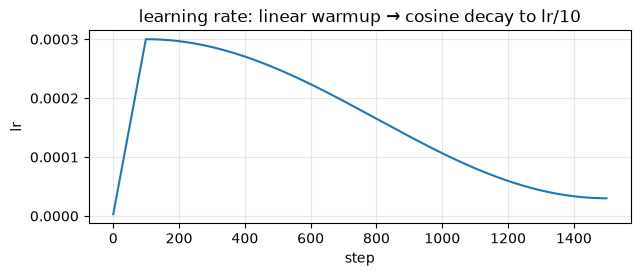

In [8]:
train_ds = TokenDataset(shard.with_name('train.bin'), SEQ_LEN)
val_ds   = TokenDataset(shard.with_name('val.bin'),   SEQ_LEN)
print(f'train windows {len(train_ds):,} | val windows {len(val_ds):,}')

tcfg = TrainConfig(
    max_steps=1500, batch_size=BATCH, grad_accum=ACCUM, seq_len=SEQ_LEN,
    lr=3e-4, warmup_steps=100, weight_decay=0.1, grad_clip=1.0,
    eval_every=250, eval_iters=20, log_every=25,
    ckpt_dir=str(ROOT/'checkpoints'), device=DEVICE,
    dtype='bfloat16' if DEVICE=='cuda' else 'float32', compile=False,
)
# Plot the schedule before committing GPU hours to it.
import matplotlib.pyplot as plt
plt.figure(figsize=(7,2.5))
plt.plot([cosine_lr(s, tcfg) for s in range(tcfg.max_steps)])
plt.title('learning rate: linear warmup → cosine decay to lr/10')
plt.xlabel('step'); plt.ylabel('lr'); plt.grid(alpha=.3); plt.show()

In [2]:
state = train(model, train_ds, val_ds, tcfg)
print('\ndone. checkpoints:', sorted(p.name for p in (ROOT/'checkpoints').glob('*.pt')))

NameError: name 'train' is not defined

## Step 5 — perplexity and the loss curve

**Perplexity = exp(loss)**: the effective number of tokens the model is
choosing between at each step. `ppl = V` means "no better than uniform";
halving perplexity means the model has genuinely halved its uncertainty.

In [ ]:
hist = [h for h in state.history if 'loss' in h]
vhist = [h for h in state.history if 'val_loss' in h]
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
ax[0].plot([h['step'] for h in hist], [h['loss'] for h in hist], label='train')
if vhist: ax[0].plot([h['step'] for h in vhist], [h['val_loss'] for h in vhist], 'o-', label='val')
ax[0].axhline(math.log(tok.vocab_size), ls='--', c='grey', label='ln(V) = uniform')
ax[0].set_xlabel('step'); ax[0].set_ylabel('cross-entropy'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].semilogy([h['step'] for h in hist], [h['ppl'] for h in hist])
ax[1].set_xlabel('step'); ax[1].set_ylabel('perplexity (log)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
final = estimate_loss(model, val_ds, tcfg, 30)
print(f'final val loss {final:.4f} | perplexity {math.exp(final):.2f} | uniform would be {tok.vocab_size}')

In [ ]:
model.eval()
prompt = 'Acme Industries'
ids = torch.tensor([tok.encode(prompt)], device=DEVICE)
with torch.inference_mode():
    out = model.generate(ids, max_new_tokens=60, temperature=0.8, top_k=40,
                         eos_id=tok.special_tokens['<|eos|>'])
print(tok.decode(out[0].tolist(), skip_special=True))
print('\nA small model trained on a small corpus produces fluent-ish nonsense.')
print('That is expected and is exactly why VERITAS never lets it assert facts')
print('unverified — see notebook 07.')

## Trade-offs

* **`torch.compile=True`** gives ~1.3–2×, at a slow first step. Worth it above
  ~1000 steps.
* **Bigger `seq_len`** helps long-range modelling but attention is `O(L²)` —
  cost quadruples when you double it.
* **`beta2 = 0.95`** (not 0.999): faster adaptation to the shifting gradient
  statistics of a short LM run.
* **`dropout = 0`** while tokens ≫ params. Turn it on only when val loss
  diverges from train loss.

Next: **04 — instruction tuning.**